# Movie Ratings Analysis

## What This Notebook Is About

This notebook introduces **exploratory data analysis (EDA)** and **confidence intervals** using a dataset of ~2,900 IMDB movies across 12 genres.

---

### What is Exploratory Data Analysis (EDA)?

EDA is the process of getting to know your data before drawing conclusions. You look at:
- **Shape**: How many rows and columns? What types are the columns?
- **Missing values**: Are there gaps in the data?
- **Distribution**: What do the values look like? Are they skewed? Are there outliers?
- **Relationships**: Do some groups behave differently?

Think of EDA as the detective work you do before writing your report.

---

### Confidence Intervals (CI) for the Mean

After exploring the data, we compute a **95% confidence interval** for the mean rating of each genre. This tells us not just *what* the average rating is, but *how confident* we can be in that estimate.

**The formula**: mean ± t* × (sd / √n)

| Term | Name | What it measures |
|---|---|---|
| mean | Sample mean | Our best estimate of the true rating |
| sd / √n | Standard Error (SE) | How uncertain we are (decreases as n grows) |
| t* | t-critical value | How wide to make the interval (accounts for small samples) |

**Key insight**: genres with *few movies* (small n) will have *wide CIs* — we're uncertain because we have little data. Genres with many movies (large n) will have *narrow CIs*.

---

### Four Visualisation Types

We use four complementary plot types, each revealing something different:

| Plot | What it shows |
|---|---|
| **Boxplot** | Five-number summary: min, Q1, median, Q3, max + outliers |
| **Histogram** | Count of movies per rating bin; good for spotting peaks and skew |
| **ECDF** | Cumulative distribution; good for comparing without shape assumptions |
| **KDE** | Smoothed histogram; good for seeing the overall density shape |

---

### Libraries Used
- **`pandas`** — data loading, filtering, grouping, aggregation
- **`scipy.stats`** — t-distribution for confidence intervals
- **`seaborn`** — FacetGrid, stripplot, pointplot, histplot, kdeplot, ecdfplot, boxplot
- **`numpy`** — `np.mean`, `np.sqrt`, `np.arange`
- **`matplotlib`** — figure sizing, axis formatting, annotations

## 1. Import Libraries

In [1]:
import pandas as pd           # DataFrames — programmable spreadsheet
import seaborn as sns          # Statistical visualisations built on matplotlib
import matplotlib.pyplot as plt  # Core plotting canvas (figure, axes, labels)
import numpy as np             # Numerical operations and array maths
from scipy import stats        # stats.t.ppf() for t-distribution critical values

import warnings
warnings.filterwarnings('ignore')   # suppress minor warnings for cleaner output

# Apply a clean plot style globally for the whole notebook.
# "ticks" = minimal style: white background, tick marks on axes, no grid by default.
sns.set_style("ticks")


## 2. Load Data

In [4]:

movies = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/movies.csv")
movies.head()


,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.9
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.7
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.0
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.1
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.0


## 3. Explore the Data

Before any analysis, get familiar with the structure, types, and quality of the dataset.

In [ ]:
# .info() is the first thing to run on any new dataset.
# It shows: number of rows, column names, data types, and non-null counts.
# This is the Python equivalent of R's str() or glimpse().
# Look for:
#   - "object" dtype = text/categorical columns
#   - "int64" / "float64" = numeric columns
#   - Non-null count < total rows → missing values in that column
movies.info()


In [ ]:
# First 5 rows -- quick sanity check
movies.head()

In [8]:
# Rich summary statistics: mean, sd, percentiles, missing values -- like skimr::skim() in R
movies.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
year,2897.0,2002.90,9.81,1920.0,1999.0,2004.0,2010.0,2016.0
duration,2897.0,109.65,22.32,37.0,95.0,105.0,119.0,330.0
gross,2897.0,57572372.01,71992380.71,703.0,12065985.0,34507079.0,75074950.0,760505847.0
budget,2897.0,40278663.68,43227939.14,218.0,11000000.0,25000000.0,55000000.0,300000000.0
cast_facebook_likes,2897.0,12303.79,20564.22,0.0,2228.0,4537.0,16785.0,656730.0
votes,2897.0,109005.27,159233.86,5.0,19586.0,55008.0,132048.0,1689764.0
reviews,2897.0,499.28,493.51,2.0,198.0,359.0,624.0,5312.0
rating,2897.0,6.39,1.06,1.6,5.8,6.5,7.1,9.3


In [9]:
# Count movies per genre -- before we filter anything
genre_counts = movies['genre'].value_counts()
print(f"Total genres: {len(genre_counts)}")
print()
print(genre_counts)

Total genres: 12

genre
Comedy         844
Action         719
Drama          484
Adventure      281
Crime          198
Biography      135
Horror         128
Animation       35
Fantasy         26
Documentary     25
Mystery         15
Sci-Fi           7
Name: count, dtype: int64


## 4. Filter Data

Genres with very few films give unreliable estimates. We keep only genres with **more than 5 movies** so that any statistics we compute are meaningful.

In [ ]:
MIN_MOVIES = 5   # Minimum number of movies a genre must have to be included

# Step 1: Count movies per genre (already computed above as `genre_counts`)
# Step 2: Filter to genres exceeding the threshold
# genre_counts > MIN_MOVIES returns a boolean Series (True/False per genre)
# [genre_counts > MIN_MOVIES] selects only the True entries
# .index gives us the genre names (not the counts)
# .tolist() converts the index to a plain Python list
genres_to_keep = genre_counts[genre_counts > MIN_MOVIES].index.tolist()

original_count = len(movies)

# Boolean filtering:
# movies['genre'].isin(genres_to_keep) → True for rows in an approved genre
# movies[...] keeps only those rows
# .copy() creates an independent copy of the DataFrame.
# Why .copy()? Without it, `movies` would be a "view" of the original,
# and pandas might show a SettingWithCopyWarning when we modify it later.
movies = movies[movies['genre'].isin(genres_to_keep)].copy()

print(f"Kept {len(genres_to_keep)} genres (>{MIN_MOVIES} movies each)")
print(f"Rows before: {original_count:,}  |  Rows after: {len(movies):,}  |  Removed: {original_count - len(movies):,}")


## 5. Distribution Plots

We use four different plot types to visualise rating distributions per genre. Each reveals something different about the data.

### 5a. Boxplots

Boxplots show the five-number summary for each genre: minimum, Q1, median, Q3, maximum. Dots outside the whiskers are outliers.

/Users/kostischristodoulou/Library/CloudStorage/Dropbox/LBS/01_websites_github_repos/data_analytics_executives/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


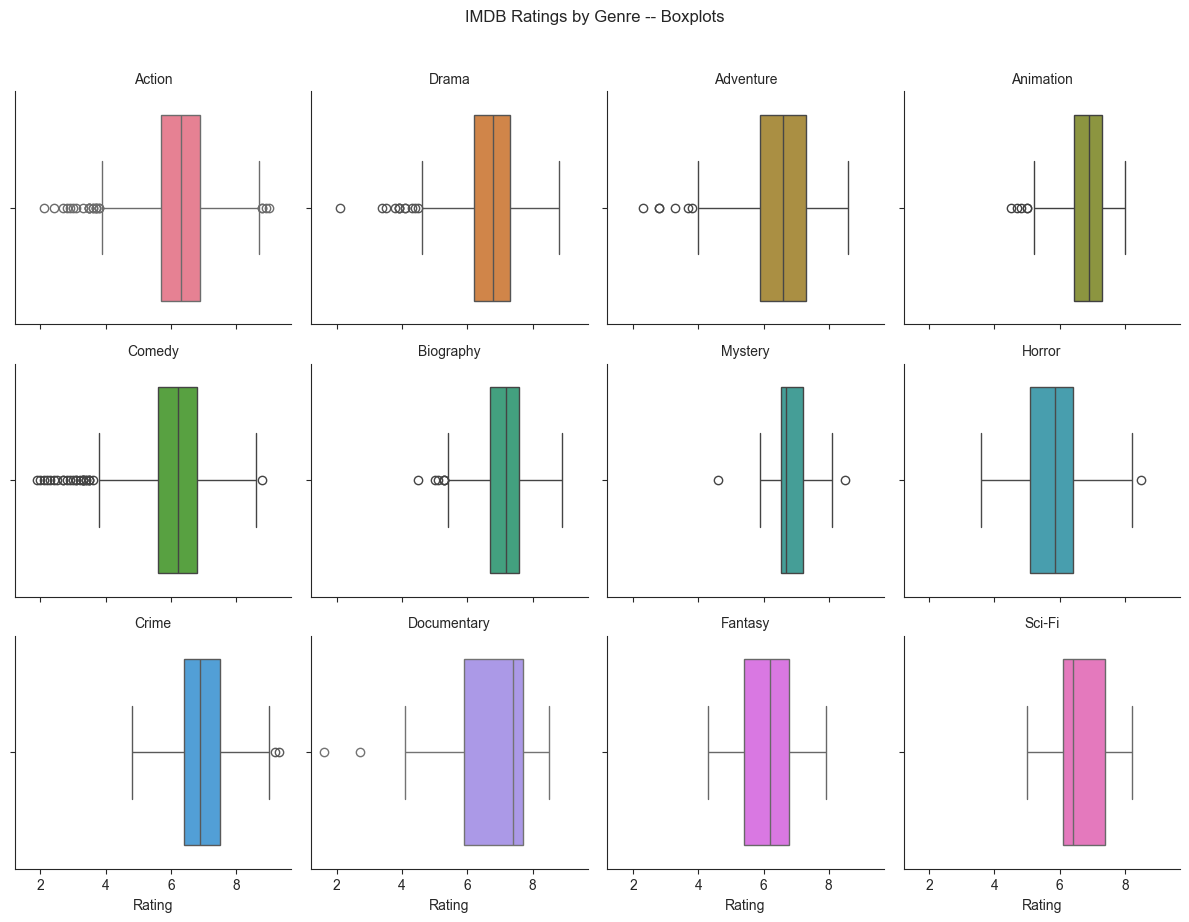

In [11]:
g = sns.FacetGrid(movies, col='genre', hue='genre', col_wrap=4, sharex=True, sharey=True)
g.map(sns.boxplot, 'rating')
g.fig.suptitle("IMDB Ratings by Genre -- Boxplots", y=1.02)
g.set_axis_labels("Rating", "")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### 5b. Histograms

Histograms show the count of movies falling into each rating bin. Useful for spotting peaks and skew.

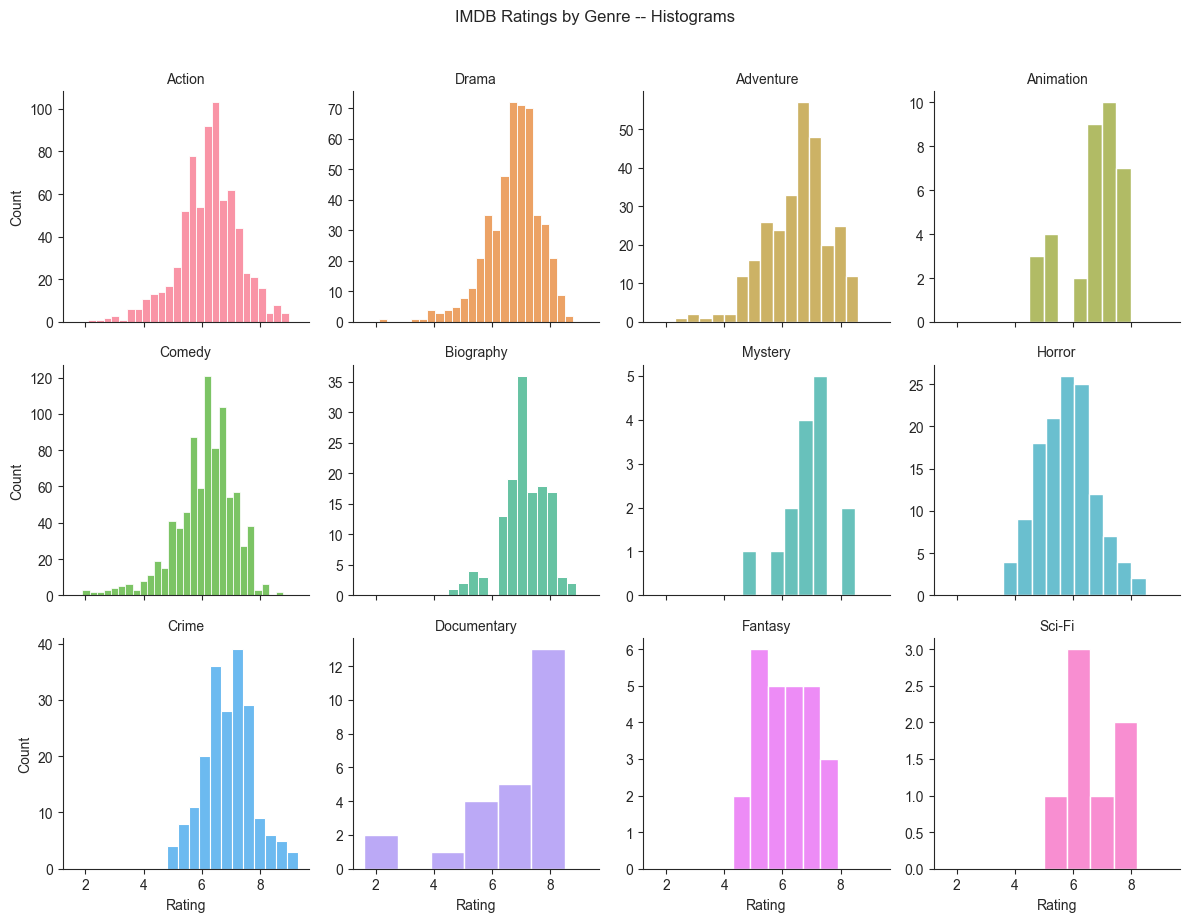

In [12]:
g = sns.FacetGrid(movies, col='genre', hue='genre', col_wrap=4, sharex=True, sharey=False)
g.map(sns.histplot, 'rating')
g.fig.suptitle("IMDB Ratings by Genre -- Histograms", y=1.02)
g.set_axis_labels("Rating", "Count")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### 5c. ECDF (Empirical Cumulative Distribution Function)

The ECDF shows what proportion of movies score at or below each rating value. Steeper sections = more movies clustered at that rating. Useful for comparing genres without assuming a bell curve.

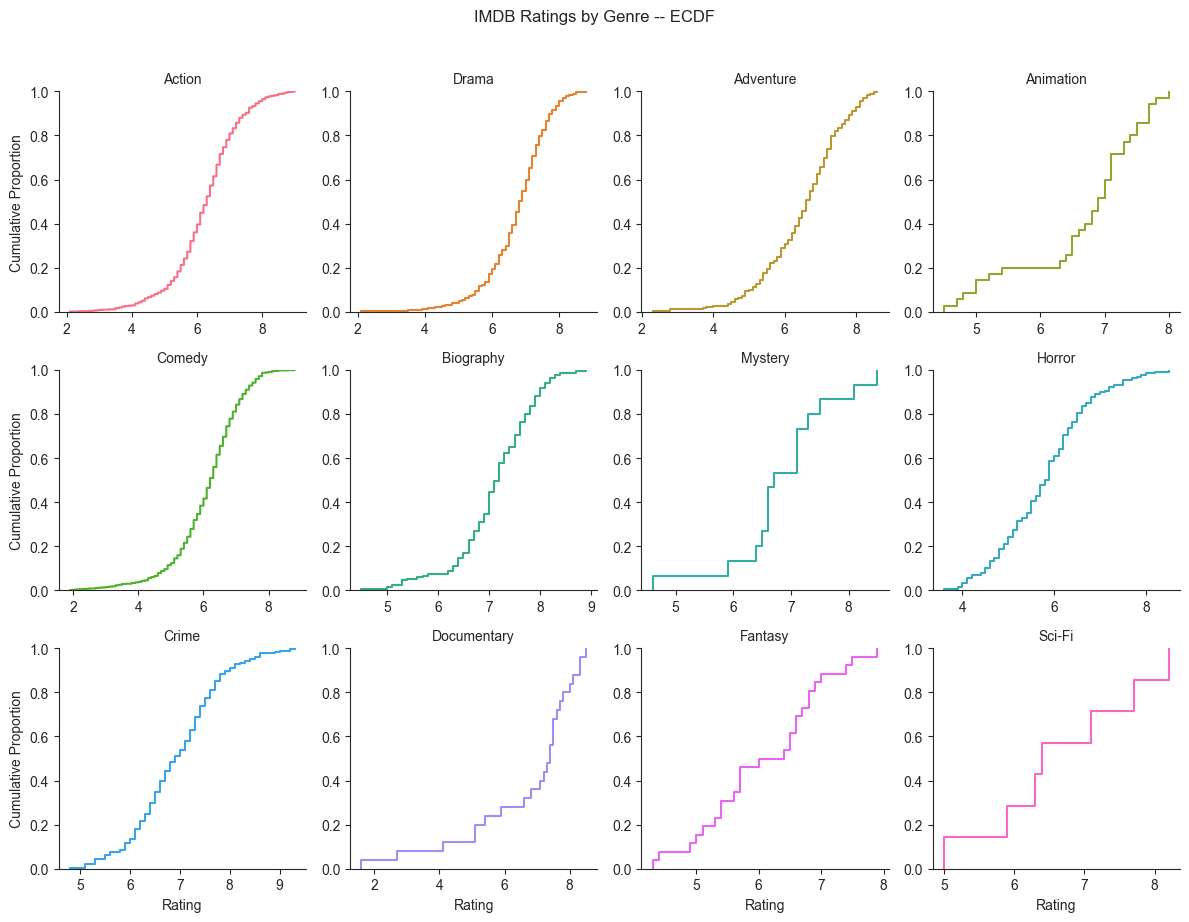

In [13]:
g = sns.FacetGrid(movies, col='genre', hue='genre', col_wrap=4, sharex=False, sharey=False)
g.map(sns.ecdfplot, 'rating')
g.fig.suptitle("IMDB Ratings by Genre -- ECDF", y=1.02)
g.set_axis_labels("Rating", "Cumulative Proportion")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### 5d. Density Plots (KDE)

Kernel Density Estimates are smoothed histograms. Higher peaks = more common ratings. Good for seeing the overall shape of each genre's rating distribution.

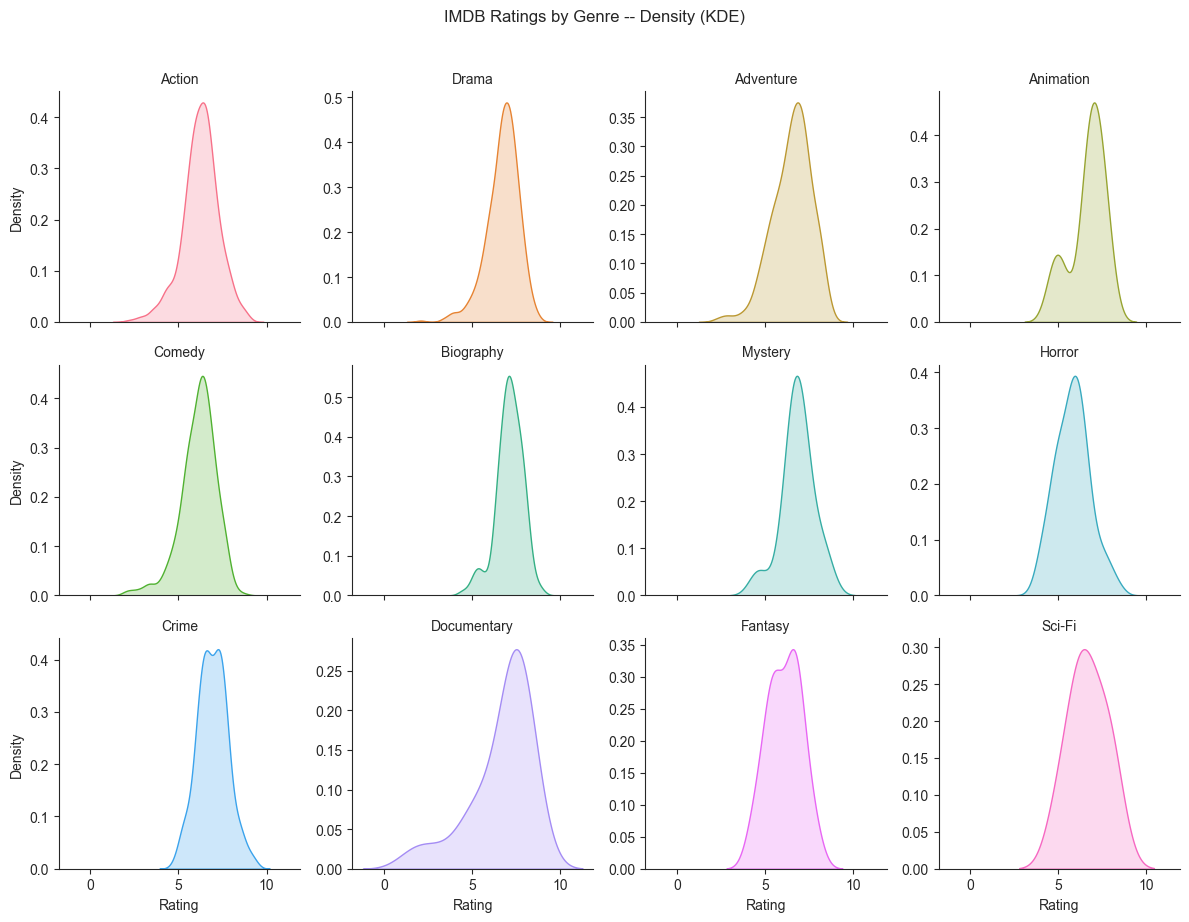

In [14]:
g = sns.FacetGrid(movies, col='genre', hue='genre', col_wrap=4, sharex=True, sharey=False)
g.map(sns.kdeplot, 'rating', fill=True)   # fill=True shades under the curve
g.fig.suptitle("IMDB Ratings by Genre -- Density (KDE)", y=1.02)
g.set_axis_labels("Rating", "Density")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

## 6. Confidence Intervals

For each genre we compute the **95% confidence interval** around the mean rating.

The formula is: `mean +/- t_critical * (sd / sqrt(n))`

- `t_critical` comes from the t-distribution (accounts for small sample sizes)
- `sd / sqrt(n)` is the **standard error** -- how uncertain we are about the mean
- Wider CI = fewer movies or more variable ratings
- If two genres' CIs overlap, we cannot confidently say their true means differ

In [5]:
# METHOD CHAINING with .groupby() → .agg() → .assign()
# Method chaining means: apply one operation, then immediately apply another
# to the result, using dots. This keeps all transformations in one block.
# Each line produces a new DataFrame that becomes the input for the next line.

genre_ci = (
    movies
    # GROUP BY GENRE: split the DataFrame into one group per genre.
    # After groupby, operations are applied to each group separately.
    .groupby('genre')['rating']      # for each genre, look at the 'rating' column only

    # AGGREGATE: collapse each group to summary statistics.
    # 'mean' → np.mean of ratings, 'std' → standard deviation, 'count' → n
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'mean_rating', 'std': 'sd_rating'})

    # ASSIGN: add new derived columns.
    # Lambda functions here are small, anonymous functions defined inline.
    # lambda x: expression(x)  is equivalent to:
    #   def my_function(x): return expression(x)
    # Here `x` is the whole DataFrame (not a single value), so we can
    # reference multiple columns at once.
    .assign(
        # t_critical: the t-distribution multiplier for a 95% CI.
        # stats.t.ppf(0.975, df) finds the t-value that leaves 2.5% in each tail.
        # df = count - 1 (degrees of freedom; penalises small samples with wider intervals)
        # For large n (e.g. 844 Comedy movies), t ≈ 1.96 (the familiar normal value).
        # For small n (e.g. 7 Sci-Fi movies), t ≈ 2.45 (wider to account for uncertainty).
        t_critical      = lambda x: stats.t.ppf(0.975, x['count'] - 1),

        # Standard error: sd / sqrt(n)
        # Measures how precisely the sample mean estimates the true mean.
        # As n grows, SE shrinks → more precise estimate → narrower CI.
        se_rating       = lambda x: x['sd_rating'] / np.sqrt(x['count']),

        # Margin of error = t* × SE (how far the CI extends either side of the mean)
        margin_of_error = lambda x: x['t_critical'] * x['se_rating'],

        # Confidence interval bounds
        rating_low      = lambda x: x['mean_rating'] - x['margin_of_error'],
        rating_high     = lambda x: x['mean_rating'] + x['margin_of_error'],
    )
    .sort_values('mean_rating', ascending=False)   # rank genres from highest to lowest rated
    .round(2)
    .reset_index()
)

display(genre_ci)


,genre,mean_rating,sd_rating,count,t_critical,se_rating,margin_of_error,rating_low,rating_high
0,Biography,7.11,0.76,135,1.98,0.07,0.13,6.98,7.24
1,Crime,6.92,0.85,198,1.97,0.06,0.12,6.81,7.04
2,Mystery,6.84,0.91,15,2.14,0.23,0.50,6.34,7.34
3,Drama,6.74,0.92,484,1.96,0.04,0.08,6.66,6.82
4,Documentary,6.66,1.77,25,2.06,0.35,0.73,5.93,7.39
5,Sci-Fi,6.66,1.09,7,2.45,0.41,1.01,5.65,7.67
6,Animation,6.65,0.97,35,2.03,0.16,0.33,6.32,6.98
7,Adventure,6.51,1.11,281,1.97,0.07,0.13,6.38,6.64
8,Action,6.23,1.04,719,1.96,0.04,0.08,6.16,6.31
9,Comedy,6.11,1.02,844,1.96,0.04,0.07,6.04,6.18


## 7. Jitter Plot with Mean and CI

Each dot is one movie. The orange diamonds show the genre mean, and error bars show the 95% CI. This lets us see both the raw spread and the statistical summary simultaneously.

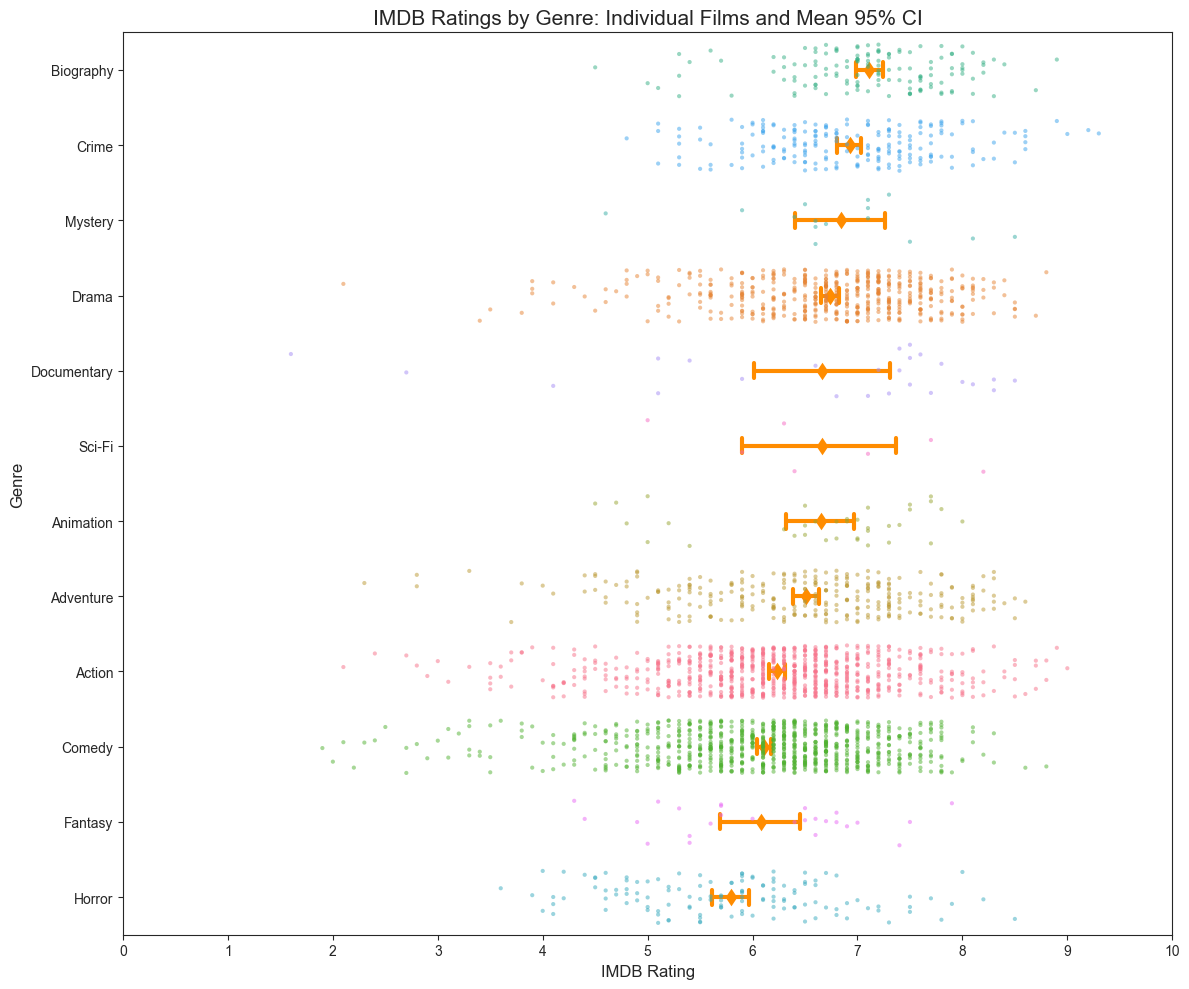

In [ ]:
# ordered_genres: the genre names sorted by mean_rating (high → low).
# Using this as `order=` in seaborn ensures the y-axis matches our sorted CI table.
ordered_genres = genre_ci['genre']   # already sorted descending by mean_rating

fig, ax = plt.subplots(figsize=(12, 10))

# ── LAYER 1: STRIP PLOT — individual movies as dots ───────────────────────────
# sns.stripplot draws each movie as a point, using jitter to prevent overlap.
# Without jitter, all movies with the same genre would stack on top of each other.
#
# jitter=0.35 → randomly nudge each dot vertically (up to 35% of a unit)
# alpha=0.5   → 50% transparency so overlapping dots are still visible
# size=3      → small dot size to reduce clutter with ~2900 movies
# hue='genre' → each genre gets a different colour (matches seaborn's default palette)
sns.stripplot(
    data=movies, 
    x='rating', 
    y='genre',
    hue='genre', 
    order=ordered_genres,
    jitter=0.35, 
    alpha=0.5, 
    size=3, 
    ax=ax
)

# ── LAYER 2: POINT PLOT — mean ± 95% CI on top of the dots ───────────────────
# sns.pointplot draws a summary statistic (estimator=np.mean) with error bars.
# We overlay it on the same Axes (`ax=ax`) as the strip plot.
#
# estimator=np.mean   → plot the mean (not median or another stat)
# errorbar=('ci', 95) → draw a 95% CI error bar using the t-distribution
# join=False          → don't draw connecting lines between groups
# color='darkorange'  → bright orange to stand out from the coloured dots
# markers='d'         → diamond shape for the mean point (easier to spot)
# scale=1.1           → slightly larger than default marker size
# capsize=0.2         → small horizontal caps at the end of the error bar
sns.pointplot(
    data=movies, x='rating', y='genre',
    order=ordered_genres,
    estimator=np.mean,
    errorbar=('ci', 95),
    join=False,
    color='darkorange',
    markers='d',
    scale=1.1,
    capsize=0.2,
    ax=ax
)

ax.set_title("IMDB Ratings by Genre: Individual Films and Mean 95% CI", fontsize=15)
ax.set_xlabel("IMDB Rating", fontsize=12)
ax.set_ylabel("Genre", fontsize=12)
ax.set_xticks(np.arange(0, 11, 1))    # show tick marks at every whole number 0–10
plt.tight_layout()
plt.show()


## 8. Error Bar Plot (CI Only)

A cleaner view: just the mean and 95% CI for each genre, with exact values labelled. Blue = lower bound, black = mean, red = upper bound.

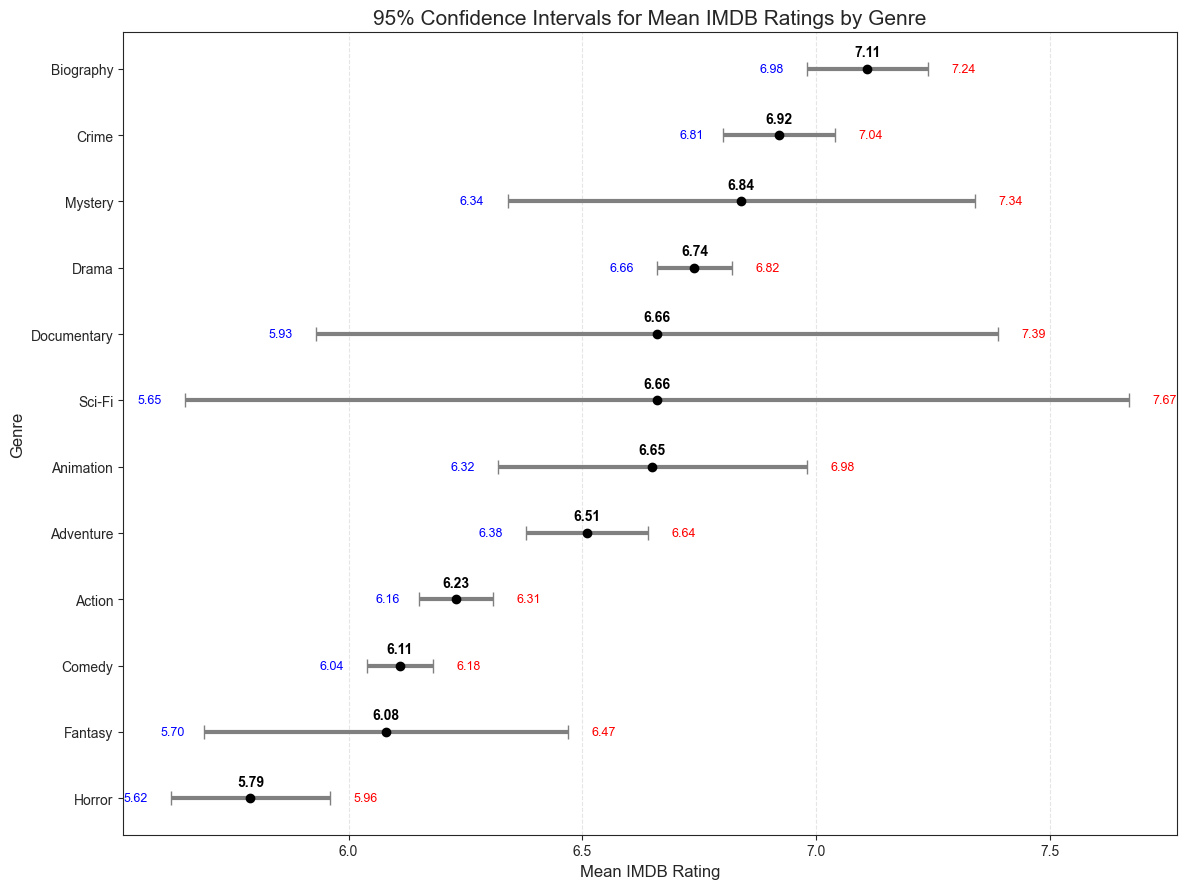

In [7]:
ci_plot = genre_ci.copy()   # already sorted descending by mean_rating

fig, ax = plt.subplots(figsize=(12, 9))

# Draw one error bar per genre
ax.errorbar(
    y=ci_plot['genre'],
    x=ci_plot['mean_rating'],
    xerr=ci_plot['margin_of_error'],
    fmt='o',          # circle for the point
    color='black',
    ecolor='gray',
    elinewidth=3,
    capsize=5
)

# Annotate with numeric values: lower (blue), mean (black bold), upper (red)
for i, row in ci_plot.iterrows():
    ax.text(row['rating_low']  - 0.05, i, f"{row['rating_low']:.2f}",
            color='blue',  ha='right',  va='center', fontsize=9)
    ax.text(row['mean_rating'],         i - 0.25, f"{row['mean_rating']:.2f}",
            color='black', ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(row['rating_high'] + 0.05, i, f"{row['rating_high']:.2f}",
            color='red',   ha='left',   va='center', fontsize=9)

ax.invert_yaxis()    # highest-rated genre at the top
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_title("95% Confidence Intervals for Mean IMDB Ratings by Genre", fontsize=15)
ax.set_xlabel("Mean IMDB Rating", fontsize=12)
ax.set_ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Interpretation Guide

| Question | Where to look |
|---|---|
| Which genres rate highest / lowest? | Sort `mean_rating` in the CI table |
| How certain are the estimates? | Width of the CI -- wider = less certain |
| Do two genres truly differ? | Overlapping CIs suggest no significant difference |
| What is the shape of each distribution? | KDE / histogram panels |
| Are there unusual films? | Dots outside whiskers in boxplots |
| Which genres have enough data? | `count` column in the CI table |

**Remember**: statistical significance (non-overlapping CIs) is not the same as practical significance. A 0.1-point difference in mean rating may be real but not meaningful to a viewer.